In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import random_split, DataLoader
from torchvision.datasets import CIFAR100
import random
from torchsummary import summary
import wandb
from sklearn.metrics import classification_report

# Set random seeds for reproducibility
torch.manual_seed(2022484)
np.random.seed(2022484)
random.seed(2022484)

In [21]:
# Experiment configs
experiment_configs = [
    {
        "run_name":   "EXP1",
        "optimizer":  "Adam",
        "learning_rate": 0.001,
        "dropout":    0.3,
        "epochs":     40,
        "batch_size": 32
    },
    {
        "run_name":   "EXP2",
        "optimizer":  "Adam",
        "learning_rate": 0.0005,
        "dropout":    0.3,
        "epochs":     40,
        "batch_size": 64
    },
    {
        "run_name":   "EXP3",
        "optimizer":  "SGD",
        "learning_rate": 0.01,
        "dropout":    0.2,
        "epochs":     40,
        "batch_size": 128
    },
    {
        "run_name":   "EXP4",
        "optimizer":  "SGD",
        "learning_rate": 0.001,
        "dropout":    0.5,
        "epochs":     40,
        "batch_size": 256
    },
    {
        "run_name":   "EXP5",
        "optimizer":  "Adam",
        "learning_rate": 0.0001,
        "dropout":    0.4,
        "epochs":     40,
        "batch_size": 64
    },
]

# Plain vs. Augmented Datasets
plain_trainset = CIFAR100(
    root='./data',
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=None, shear=None),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset_aug = CIFAR100(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])
testset = CIFAR100(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

# Split train dataset into train & validation
train_size = int(0.8 * len(trainset_aug))
val_size   = len(trainset_aug) - train_size
train_dataset, val_dataset = random_split(trainset_aug, [train_size, val_size])



In [ ]:
# Show Images from plain_trainset and trainset_aug
def show_images(num_classes=10, images_per_class=5):
    classes = plain_trainset.classes
    chosen_class_indices = random.sample(range(len(classes)), num_classes)

    fig, axes = plt.subplots(images_per_class, num_classes,
                             figsize=(2*num_classes, 2*images_per_class))

    for col, cls_idx in enumerate(chosen_class_indices):
        all_indices = [i for i, (_, label) in enumerate(plain_trainset) if label == cls_idx]
        selected_indices = random.sample(all_indices, images_per_class)

        for row, sample_idx in enumerate(selected_indices):
            img, label = plain_trainset[sample_idx]
            img_np = img.permute(1, 2, 0).numpy()  # [H,W,3] in [0,1]
            axes[row, col].imshow(img_np)
            axes[row, col].axis('off')
            if row == 0:
                axes[row, col].set_title(classes[cls_idx], fontsize=9)

    plt.tight_layout()
    plt.show()

def show_images_aug(num_classes=10, images_per_class=5):
    classes = trainset_aug.classes
    chosen_class_indices = random.sample(range(len(classes)), num_classes)

    fig, axes = plt.subplots(images_per_class, num_classes,
                             figsize=(2*num_classes, 2*images_per_class))

    for col, cls_idx in enumerate(chosen_class_indices):
        all_indices = [i for i, (_, label) in enumerate(trainset_aug) if label == cls_idx]
        selected_indices = random.sample(all_indices, images_per_class)

        for row, sample_idx in enumerate(selected_indices):
            img, label = trainset_aug[sample_idx]
            img = img * 0.5 + 0.5
            img_np = img.permute(1, 2, 0).numpy()
            axes[row, col].imshow(img_np)
            axes[row, col].axis('off')
            if row == 0:
                axes[row, col].set_title(classes[cls_idx], fontsize=9)

    plt.tight_layout()
    plt.show()


In [23]:
# CNN Model Class with show_summary() method
class CustomCNN(nn.Module):
    def __init__(self, dropout=0.3):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(128 * 4 * 4, 256)
        self.fc2   = nn.Linear(256, 100)
        self.relu  = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # [32,16,16]
        x = self.pool(self.relu(self.conv2(x)))  # [64,8,8]
        x = self.pool(self.relu(self.conv3(x)))  # [128,4,4]
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x
    
    def show_summary(self, input_size=(3,32,32), device='cuda'):
        self.to(device)
        summary(self, input_size=input_size, device=device)

# Create Optimizer Function
def create_optimizer(parameters, opt_type="Adam", lr=1e-3):
    if opt_type.lower() == "adam":
        return optim.Adam(parameters, lr=lr)
    elif opt_type.lower() == "sgd":
        return optim.SGD(parameters, lr=lr, momentum=0.9)
    else:
        raise ValueError(f"Unsupported optimizer type: {opt_type}")

In [24]:
# Training Function
def train_model(model, train_loader, val_loader, epochs=10, run_name=""):
    device = torch.device("cuda")
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            model.optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            model.optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc  = 100.0 * correct / total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = 100.0 * val_correct / val_total

        print(f"[{run_name}] Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        wandb.log({
            "Train Loss": train_loss,
            "Train Accuracy": train_acc,
            "Validation Loss": val_loss,
            "Validation Accuracy": val_acc,
            "epoch": epoch + 1
        })

# Evaluation Function with classification_report
def evaluate_model(model, test_loader, class_names):
    device = torch.device("cuda")
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        zero_division=0
    )
    print("Classification Report:\n", report)
    return report

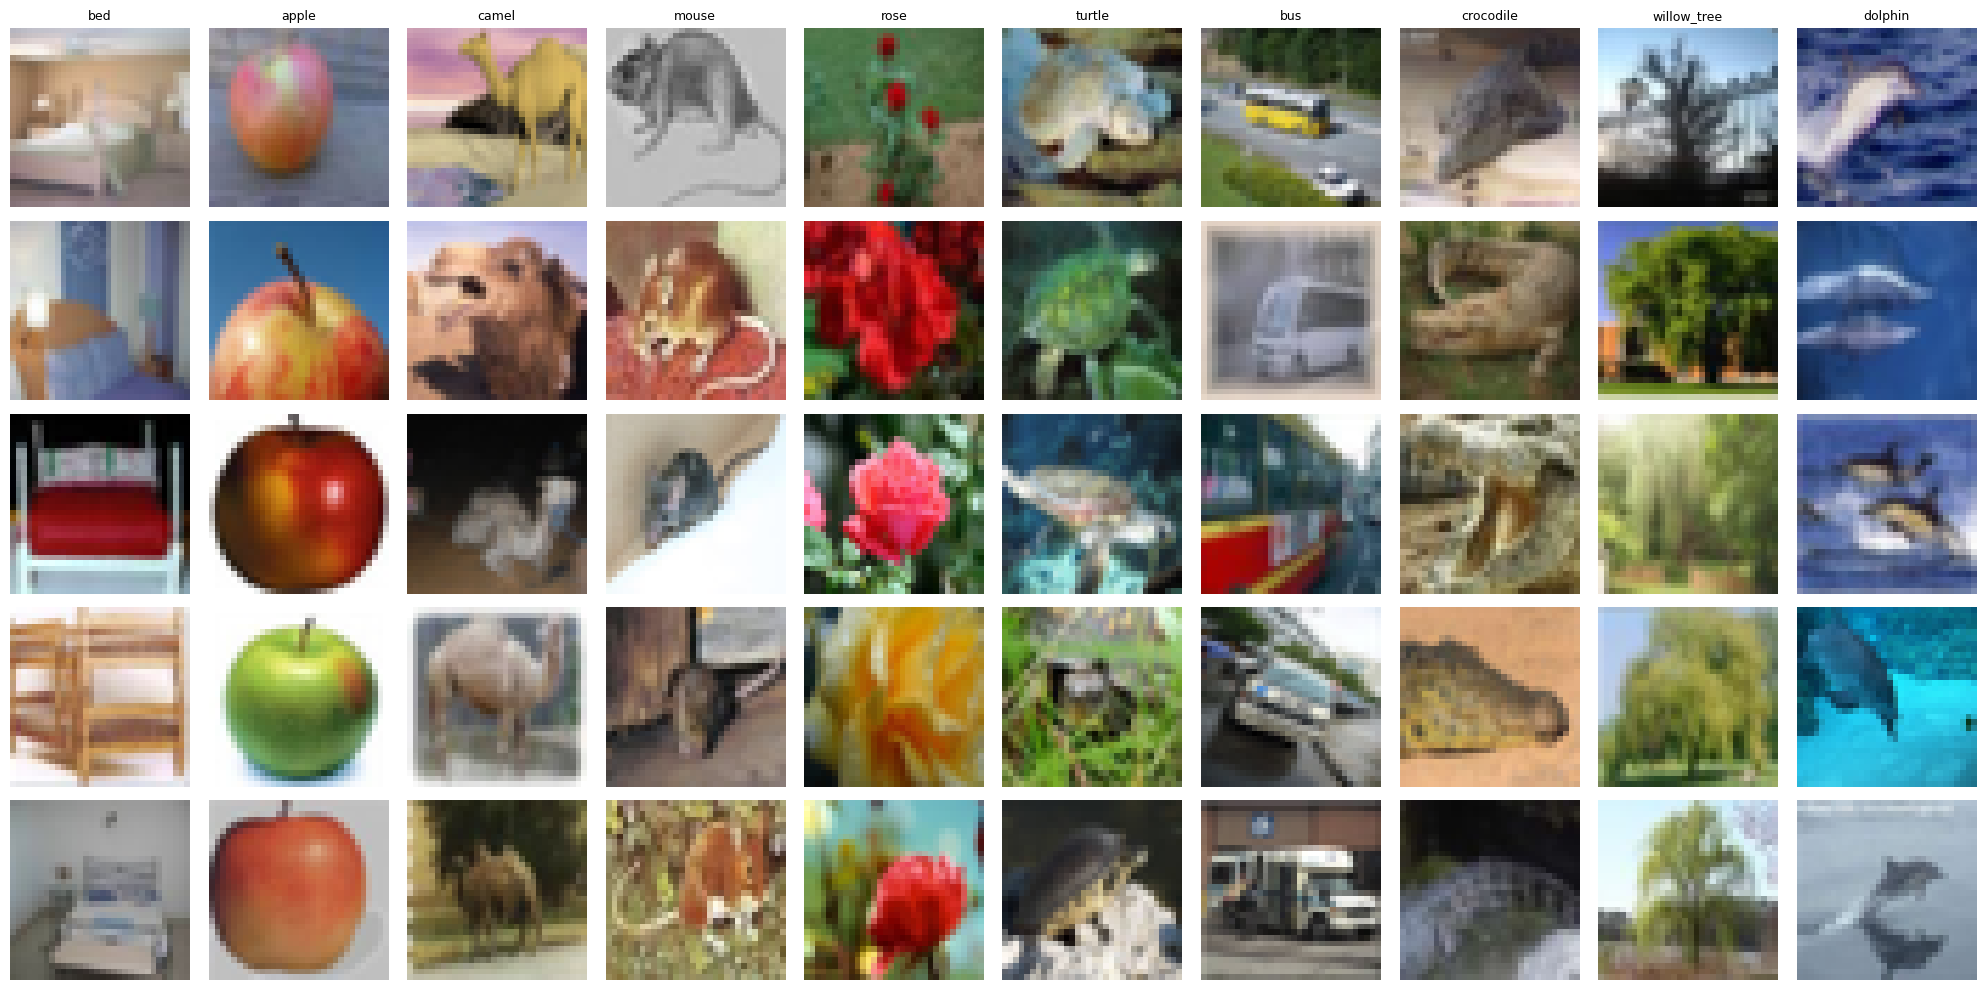

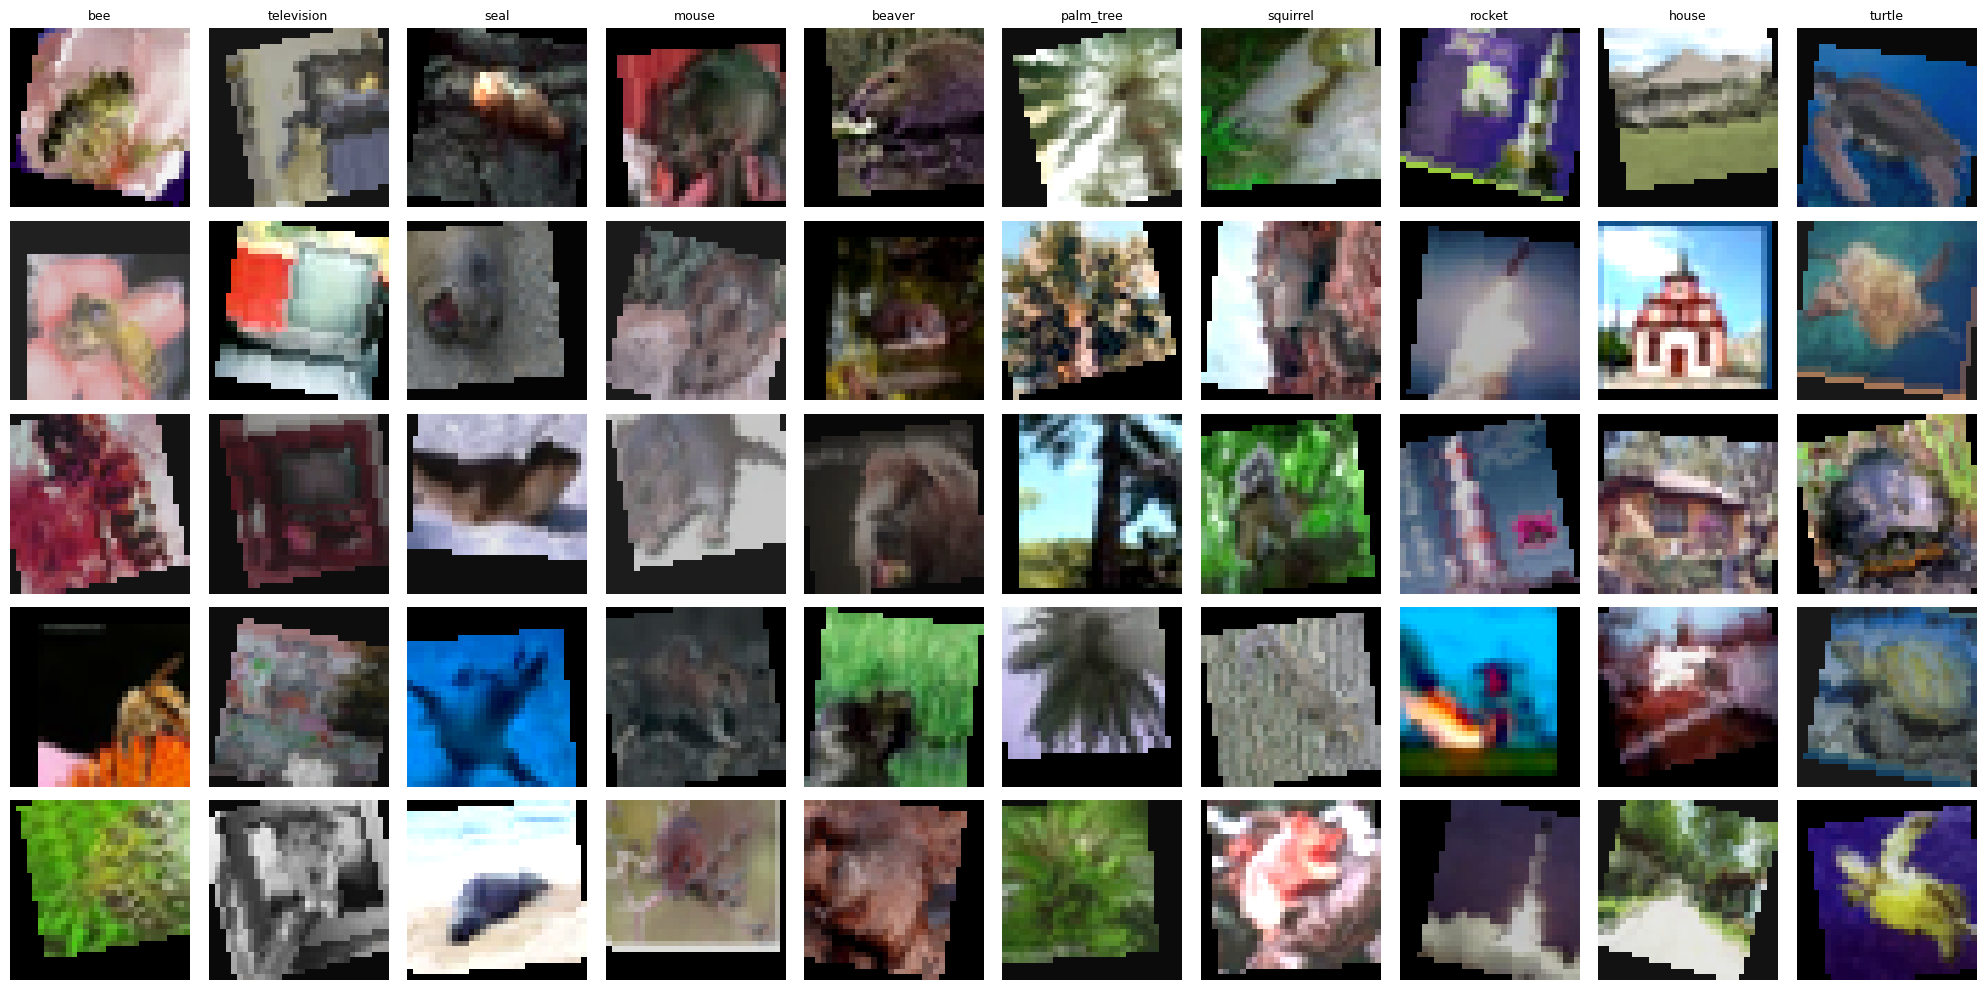

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
              ReLU-2           [-1, 32, 32, 32]               0
         MaxPool2d-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 64, 16, 16]          18,496
              ReLU-5           [-1, 64, 16, 16]               0
         MaxPool2d-6             [-1, 64, 8, 8]               0
            Conv2d-7            [-1, 128, 8, 8]          73,856
              ReLU-8            [-1, 128, 8, 8]               0
         MaxPool2d-9            [-1, 128, 4, 4]               0
           Linear-10                  [-1, 256]         524,544
             ReLU-11                  [-1, 256]               0
          Dropout-12                  [-1, 256]               0
           Linear-13                  [-1, 100]          25,700
Total params: 643,492
Trainable params:

In [ ]:
# Show 2 small image grid
show_images()
show_images_aug()

# Summarize the model
temp_model = CustomCNN(dropout=0.3)
temp_model.show_summary((3,32,32), device='cuda')

In [ ]:
# Main Experiments
for exp_cfg in experiment_configs:
    wandb.init(
        project="CIFAR100",
        name=exp_cfg["run_name"],
        config=exp_cfg,
        reinit=True
    )
    config = wandb.config

    # Create model with the chosen dropout
    model = CustomCNN(dropout=config.dropout).to("cuda")

    # Create DataLoaders with the chosen batch_size
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, num_workers=2)
    val_loader   = DataLoader(val_dataset,   batch_size=config.batch_size, shuffle=False, num_workers=2)
    test_loader_ = DataLoader(testset,       batch_size=config.batch_size, shuffle=False, num_workers=2)

    # Create optimizer
    model.optimizer = create_optimizer(
        model.parameters(),
        opt_type=config.optimizer,
        lr=config.learning_rate
    )
    
    wandb.watch(model, log="all")

    # Train
    train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=config.epochs,
        run_name=exp_cfg["run_name"]
    )

    # Evaluate
    print(f"\n--- Testing {exp_cfg['run_name']} ---")
    report = evaluate_model(model, test_loader_, class_names=testset.classes)
    torch.save(model.state_dict(), f"{exp_cfg['run_name']}_weights.pth")
    wandb.log({"classification_report": report})
    wandb.finish()

wandb: Currently logged in as: shreyansh22484 (shreyansh22484-indraprastha-institute-of-information-tec). Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


[EXP1] Epoch [1/40] Train Loss: 4.1810, Train Acc: 5.71% | Val Loss: 3.8743, Val Acc: 10.16%
[EXP1] Epoch [2/40] Train Loss: 3.8382, Train Acc: 10.71% | Val Loss: 3.6454, Val Acc: 13.64%
[EXP1] Epoch [3/40] Train Loss: 3.6598, Train Acc: 13.48% | Val Loss: 3.5096, Val Acc: 15.81%
[EXP1] Epoch [4/40] Train Loss: 3.5446, Train Acc: 15.72% | Val Loss: 3.3856, Val Acc: 18.13%
[EXP1] Epoch [5/40] Train Loss: 3.4634, Train Acc: 17.09% | Val Loss: 3.3323, Val Acc: 19.77%
[EXP1] Epoch [6/40] Train Loss: 3.4032, Train Acc: 17.78% | Val Loss: 3.2428, Val Acc: 20.94%
[EXP1] Epoch [7/40] Train Loss: 3.3428, Train Acc: 19.06% | Val Loss: 3.2164, Val Acc: 21.72%
[EXP1] Epoch [8/40] Train Loss: 3.2955, Train Acc: 19.75% | Val Loss: 3.1806, Val Acc: 22.19%
[EXP1] Epoch [9/40] Train Loss: 3.2612, Train Acc: 20.67% | Val Loss: 3.1490, Val Acc: 22.66%
[EXP1] Epoch [10/40] Train Loss: 3.2223, Train Acc: 21.07% | Val Loss: 3.0865, Val Acc: 24.14%
[EXP1] Epoch [11/40] Train Loss: 3.1899, Train Acc: 21.77% |

Train Accuracy,▁▂▃▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████
Train Loss,█▆▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
Validation Accuracy,▁▂▃▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█▇███████████
Validation Loss,█▇▆▅▅▄▄▄▄▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
Train Accuracy,29.1275
Train Loss,2.79219
Validation Accuracy,31.04
Validation Loss,2.71387
classification_report,preci...
epoch,40


[EXP2] Epoch [1/40] Train Loss: 4.2429, Train Acc: 4.92% | Val Loss: 3.9810, Val Acc: 8.59%
[EXP2] Epoch [2/40] Train Loss: 3.8988, Train Acc: 9.65% | Val Loss: 3.7242, Val Acc: 12.99%
[EXP2] Epoch [3/40] Train Loss: 3.6893, Train Acc: 13.06% | Val Loss: 3.5205, Val Acc: 16.32%
[EXP2] Epoch [4/40] Train Loss: 3.5458, Train Acc: 15.64% | Val Loss: 3.3974, Val Acc: 19.21%
[EXP2] Epoch [5/40] Train Loss: 3.4399, Train Acc: 17.10% | Val Loss: 3.2887, Val Acc: 19.76%
[EXP2] Epoch [6/40] Train Loss: 3.3569, Train Acc: 18.77% | Val Loss: 3.2241, Val Acc: 21.32%
[EXP2] Epoch [7/40] Train Loss: 3.2864, Train Acc: 19.84% | Val Loss: 3.1745, Val Acc: 22.76%
[EXP2] Epoch [8/40] Train Loss: 3.2174, Train Acc: 21.33% | Val Loss: 3.0977, Val Acc: 23.61%
[EXP2] Epoch [9/40] Train Loss: 3.1605, Train Acc: 22.27% | Val Loss: 3.0145, Val Acc: 26.03%
[EXP2] Epoch [10/40] Train Loss: 3.1176, Train Acc: 23.11% | Val Loss: 3.0080, Val Acc: 26.44%
[EXP2] Epoch [11/40] Train Loss: 3.0598, Train Acc: 24.56% | V

Train Accuracy,▁▂▃▃▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇████████
Train Loss,█▇▆▅▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
Validation Accuracy,▁▂▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▆▇▇▇▇▇▇▇▇▇██▇███████
Validation Loss,█▇▆▅▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
Train Accuracy,36.3125
Train Loss,2.45721
Validation Accuracy,37.13
Validation Loss,2.45039
classification_report,preci...
epoch,40


...

Train Accuracy,▁▂▂▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████
Train Loss,█▇▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
Validation Accuracy,▁▂▂▃▃▃▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇█▇███████
Validation Loss,█▇▆▆▅▅▅▅▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
Train Accuracy,40.585
Train Loss,2.26963
Validation Accuracy,39.2
Validation Loss,2.34541
classification_report,preci...
epoch,40


[EXP4] Epoch [1/40] Train Loss: 4.6058, Train Acc: 1.00% | Val Loss: 4.6064, Val Acc: 1.10%
[EXP4] Epoch [2/40] Train Loss: 4.6051, Train Acc: 0.96% | Val Loss: 4.6058, Val Acc: 1.19%
[EXP4] Epoch [3/40] Train Loss: 4.6046, Train Acc: 1.15% | Val Loss: 4.6053, Val Acc: 1.28%
[EXP4] Epoch [4/40] Train Loss: 4.6039, Train Acc: 1.15% | Val Loss: 4.6048, Val Acc: 1.17%
[EXP4] Epoch [5/40] Train Loss: 4.6031, Train Acc: 1.22% | Val Loss: 4.6041, Val Acc: 1.47%
[EXP4] Epoch [6/40] Train Loss: 4.6027, Train Acc: 1.33% | Val Loss: 4.6034, Val Acc: 1.50%
[EXP4] Epoch [7/40] Train Loss: 4.6016, Train Acc: 1.30% | Val Loss: 4.6025, Val Acc: 1.71%
[EXP4] Epoch [8/40] Train Loss: 4.6005, Train Acc: 1.46% | Val Loss: 4.6014, Val Acc: 1.80%
[EXP4] Epoch [9/40] Train Loss: 4.5992, Train Acc: 1.54% | Val Loss: 4.6000, Val Acc: 2.11%
[EXP4] Epoch [10/40] Train Loss: 4.5978, Train Acc: 1.62% | Val Loss: 4.5982, Val Acc: 2.25%
[EXP4] Epoch [11/40] Train Loss: 4.5952, Train Acc: 1.75% | Val Loss: 4.5953, V

Train Accuracy,▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇███
Train Loss,██████████████▇▇▇▆▆▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁
Validation Accuracy,▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇████
Validation Loss,██████████████▇▇▆▆▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
Train Accuracy,8.3725
Train Loss,4.02998
Validation Accuracy,10.26
Validation Loss,3.94291
classification_report,preci...
epoch,40


[EXP5] Epoch [1/40] Train Loss: 4.4214, Train Acc: 3.13% | Val Loss: 4.2060, Val Acc: 5.99%
[EXP5] Epoch [2/40] Train Loss: 4.1983, Train Acc: 5.65% | Val Loss: 4.0436, Val Acc: 8.65%
[EXP5] Epoch [3/40] Train Loss: 4.0750, Train Acc: 7.51% | Val Loss: 3.9455, Val Acc: 10.40%
[EXP5] Epoch [4/40] Train Loss: 3.9811, Train Acc: 8.95% | Val Loss: 3.8501, Val Acc: 11.74%
[EXP5] Epoch [5/40] Train Loss: 3.9025, Train Acc: 10.10% | Val Loss: 3.7829, Val Acc: 12.29%
[EXP5] Epoch [6/40] Train Loss: 3.8368, Train Acc: 11.04% | Val Loss: 3.7165, Val Acc: 13.23%
[EXP5] Epoch [7/40] Train Loss: 3.7785, Train Acc: 11.71% | Val Loss: 3.6520, Val Acc: 14.62%
[EXP5] Epoch [8/40] Train Loss: 3.7280, Train Acc: 12.68% | Val Loss: 3.6142, Val Acc: 15.48%
[EXP5] Epoch [9/40] Train Loss: 3.6801, Train Acc: 13.53% | Val Loss: 3.5627, Val Acc: 15.88%
[EXP5] Epoch [10/40] Train Loss: 3.6363, Train Acc: 14.22% | Val Loss: 3.5327, Val Acc: 16.47%
[EXP5] Epoch [11/40] Train Loss: 3.6058, Train Acc: 14.61% | Val 

Train Accuracy,▁▂▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇█████████
Train Loss,█▇▆▆▅▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
Validation Accuracy,▁▂▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████
Validation Loss,█▇▆▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
Train Accuracy,23.5375
Train Loss,3.12328
Validation Accuracy,25.74
Validation Loss,3.03323
classification_report,preci...
epoch,40


In [ ]:

# Over/Underfitting Demonstration (SmallCNN & LargeCNN)
class SmallCNN(nn.Module):
    def __init__(self, dropout=0.0):
        super(SmallCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(32 * 8 * 8, 64)
        self.fc2   = nn.Linear(64, 100)
        self.relu  = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # -> [16,16,16]
        x = self.pool(self.relu(self.conv2(x)))  # -> [32,8,8]
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

class LargeCNN(nn.Module):
    def __init__(self, dropout=0.0):
        super(LargeCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64,  kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        # No final pool -> 256x4x4 = 4096
        self.fc1   = nn.Linear(4096, 512)
        self.fc2   = nn.Linear(512, 100)
        self.relu  = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # (64,16,16)
        x = self.pool(self.relu(self.conv2(x)))   # (128,8,8)
        x = self.pool(self.relu(self.conv3(x)))   # (128,4,4)
        x = self.relu(self.conv4(x))              # (256,4,4)
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# runs to show Over/Underfitting
over_under_configs = [
    {
        "run_name":     "LargeCNN_Overfit",
        "model_type":   "large",
        "optimizer":    "Adam",
        "learning_rate": 0.001,
        "dropout":      0.0,  # no dropout => easier overfit if net has big capacity
        "epochs":       20,
        "batch_size":   64
    },
    {
        "run_name":     "SmallCNN_Underfit",
        "model_type":   "small",
        "optimizer":    "Adam",
        "learning_rate": 0.001,
        "dropout":      0.0,  # no dropout, small net => likely underfit
        "epochs":       20,
        "batch_size":   64
    }
]

In [ ]:
for cfg in over_under_configs:
    wandb.init(
        project="CIFAR100",
        name=cfg["run_name"],
        config=cfg,
        reinit=True
    )
    config = wandb.config

    # Build the requested architecture
    if cfg["model_type"] == "small":
        model = SmallCNN(dropout=config.dropout).to("cuda")
    elif cfg["model_type"] == "large":
        model = LargeCNN(dropout=config.dropout).to("cuda")
    else:
        raise ValueError("Unknown model_type for over/underfitting demonstration.")

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, num_workers=2)
    val_loader   = DataLoader(val_dataset,   batch_size=config.batch_size, shuffle=False, num_workers=2)
    test_loader_ = DataLoader(testset,       batch_size=config.batch_size, shuffle=False, num_workers=2)

    # Optimizer
    model.optimizer = create_optimizer(
        model.parameters(),
        opt_type=config.optimizer,
        lr=config.learning_rate
    )

    # Track model in W&B
    wandb.watch(model, log="all")

    # Train
    train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=config.epochs,
        run_name=config["run_name"]
    )

    # Evaluate
    print(f"\n--- Testing {config['run_name']} ---")
    report = evaluate_model(model, test_loader_, class_names=testset.classes)
    torch.save(model.state_dict(), f"{config['run_name']}_weights.pth")
    wandb.log({"classification_report": report})
    wandb.finish()

print("Done demonstrating overfitting (LargeCNN) and underfitting (SmallCNN).")

[LargeCNN_Overfit] Epoch [1/20] Train Loss: 4.1837, Train Acc: 5.37% | Val Loss: 3.8724, Val Acc: 9.86%
[LargeCNN_Overfit] Epoch [2/20] Train Loss: 3.7204, Train Acc: 12.09% | Val Loss: 3.5954, Val Acc: 14.85%
[LargeCNN_Overfit] Epoch [3/20] Train Loss: 3.4725, Train Acc: 16.69% | Val Loss: 3.4550, Val Acc: 17.89%
[LargeCNN_Overfit] Epoch [4/20] Train Loss: 3.3000, Train Acc: 19.86% | Val Loss: 3.2453, Val Acc: 21.48%
[LargeCNN_Overfit] Epoch [5/20] Train Loss: 3.1591, Train Acc: 22.37% | Val Loss: 3.1668, Val Acc: 22.94%
[LargeCNN_Overfit] Epoch [6/20] Train Loss: 3.0603, Train Acc: 24.30% | Val Loss: 3.0816, Val Acc: 24.83%
[LargeCNN_Overfit] Epoch [7/20] Train Loss: 2.9572, Train Acc: 26.24% | Val Loss: 3.0119, Val Acc: 25.80%
[LargeCNN_Overfit] Epoch [8/20] Train Loss: 2.8748, Train Acc: 27.95% | Val Loss: 2.9721, Val Acc: 26.66%
[LargeCNN_Overfit] Epoch [9/20] Train Loss: 2.8058, Train Acc: 29.37% | Val Loss: 2.9179, Val Acc: 27.84%
[LargeCNN_Overfit] Epoch [10/20] Train Loss: 2.7

Train Accuracy,▁▂▃▄▅▅▅▆▆▆▇▇▇▇▇▇▇███
Train Loss,█▆▅▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁
Validation Accuracy,▁▂▃▄▅▅▆▆▆▆▇▇▇█▇█████
Validation Loss,█▆▆▄▄▄▃▃▃▃▂▂▂▁▂▁▁▁▁▁
epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
Train Accuracy,38.685
Train Loss,2.36272
Validation Accuracy,33.31
Validation Loss,2.64488
classification_report,preci...
epoch,20


[SmallCNN_Underfit] Epoch [1/20] Train Loss: 4.1854, Train Acc: 6.02% | Val Loss: 3.9535, Val Acc: 8.88%
[SmallCNN_Underfit] Epoch [2/20] Train Loss: 3.8296, Train Acc: 10.88% | Val Loss: 3.7696, Val Acc: 12.20%
[SmallCNN_Underfit] Epoch [3/20] Train Loss: 3.6700, Train Acc: 13.54% | Val Loss: 3.6308, Val Acc: 14.32%
[SmallCNN_Underfit] Epoch [4/20] Train Loss: 3.5456, Train Acc: 15.64% | Val Loss: 3.4975, Val Acc: 16.67%
[SmallCNN_Underfit] Epoch [5/20] Train Loss: 3.4469, Train Acc: 17.43% | Val Loss: 3.4352, Val Acc: 17.71%
[SmallCNN_Underfit] Epoch [6/20] Train Loss: 3.3778, Train Acc: 18.59% | Val Loss: 3.3551, Val Acc: 19.45%
[SmallCNN_Underfit] Epoch [7/20] Train Loss: 3.3216, Train Acc: 19.64% | Val Loss: 3.3338, Val Acc: 19.92%
[SmallCNN_Underfit] Epoch [8/20] Train Loss: 3.2781, Train Acc: 20.46% | Val Loss: 3.2819, Val Acc: 21.41%
[SmallCNN_Underfit] Epoch [9/20] Train Loss: 3.2485, Train Acc: 21.32% | Val Loss: 3.2634, Val Acc: 20.99%
[SmallCNN_Underfit] Epoch [10/20] Train

Train Accuracy,▁▃▄▄▅▆▆▆▆▇▇▇▇▇██████
Train Loss,█▆▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁
Validation Accuracy,▁▂▃▄▅▆▆▇▆▇▇▇▇█▇█████
Validation Loss,█▇▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁
epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
Train Accuracy,25.57
Train Loss,3.02678
Validation Accuracy,24.2
Validation Loss,3.10877
classification_report,preci...
epoch,20


Done demonstrating overfitting (LargeCNN) and underfitting (SmallCNN).


# Report for Question 1

## 1. Data Preparation and Augmentation

### Dataset and Splitting
- **Dataset:** I used the CIFAR‑100 dataset, which contains 100 classes of 32×32 color images.
- **Splitting:** I maintained the provided train-test split and created a validation set from 20% of the training data.
- **Reason:** Splitting the training data into training and validation sets allows me to monitor model performance during training, tune hyperparameters effectively, and prevent overfitting by keeping the test set independent for final evaluation.

### Data Augmentation
I worked with two versions of the training set:
- **Plain Training Set:** Used for visualizing the original color images in a 5×10 grid.
- **Augmented Training Set:** I applied on-the-fly data augmentation using torchvision transforms. The augmentations include:
  - **Random Horizontal Flip & Random Crop:** These introduce translational invariance.
  - **Random Affine Transformations:** They provide rotation and translation variations.
  - **Color Jitter (brightness, contrast, saturation, hue):** This enhances color variability.
- **Reason:** These augmentations help the model learn robust features by simulating different viewing conditions and slight variations in the images. This, in turn, improves generalization and overall performance.

---

## 2. Custom CNN Architecture

### Model Design
- I implemented a custom CNN architecture that consists of:
  - Three convolutional layers followed by max-pooling layers,
  - A fully connected (FC) layer,
  - A final classification layer.
- **Regularization & Activation:** I used Dropout and ReLU activations for regularization and to introduce non-linearity.
- **Model Summary:** The network contains 643,492 trainable parameters, as shown by the output from `torchsummary`.
  
**Reason:**
- **Convolutional Layers & Pooling:** These layers extract hierarchical spatial features.
- **Fully Connected Layers:** They map the extracted features to the class scores.
- **Dropout:** This helps reduce overfitting.
- **Custom Design:** Although the design is inspired by standard architectures (e.g., VGG-Net), I implemented it from scratch to comply with the assignment requirement of not using pretrained weights.

---

## 3. Training Setup and Hyperparameter Experiments

### Training Procedure
- **Loss Function:** I used Cross-Entropy Loss.
- **Optimizers:** Depending on the experiment, I used both Adam and SGD.
- **Hyperparameter Configurations:** I experimented with different configurations (EXP1 to EXP5) by varying the learning rate, dropout, optimizer, and batch size.
- **Live Monitoring:** I utilized Weights & Biases (W&B) to monitor training and validation loss and accuracy in real time.

**Reason:**
- **Hyperparameter Tuning:** Experimenting with different hyperparameter sets demonstrates their impact on convergence and performance. For instance, using a lower learning rate or a different optimizer resulted in different convergence speeds and accuracy levels.
- **Live Monitoring:** Tracking loss and accuracy curves in real time via W&B helped me compare performance visually and make informed decisions on hyperparameter tuning.

---

## 4. Overfitting and Underfitting Analysis

### Additional Experiments
- **LargeCNN (Overfitting):**  
  - I implemented a larger network with four convolutional layers (without dropout).  
  - **Observation:** This larger model showed a significantly decreasing training loss while the validation loss plateaued or even increased slightly, which is a clear sign of overfitting.
  
- **SmallCNN (Underfitting):**  
  - I implemented a smaller network with only two convolutional layers.  
  - **Observation:** Both training and validation losses remained high, indicating that the model is too simple (underfitting) and unable to capture the data's complexity.

### Methods to Overcome:
- **Overfitting:**  
  - I can use techniques such as adding dropout, applying weight decay, and incorporating additional data augmentation to improve generalization.
- **Underfitting:**  
  - Increasing the model capacity by adding more layers or filters or by adopting a more complex architecture may help the model learn more robust features.

---

## 5. Summary and Conclusions

### Overall Findings:
- **Hyperparameter Impact:**  
  - My experiments with various hyperparameter settings (e.g., using a learning rate of 0.0005 with Adam in EXP2) showed that certain configurations can significantly improve validation performance, with some setups achieving around 37% accuracy.
- **Live Monitoring:**  
  - The use of Weights & Biases allowed me to visualize training dynamics (loss and accuracy curves) effectively, which facilitated hyperparameter tuning.
- **Overfitting vs. Underfitting:**  
  - Additional experiments with the LargeCNN and SmallCNN demonstrated the need to balance model capacity and regularization. The larger model tended to overfit (low training loss but higher validation loss), while the smaller model underfit (high losses on both training and validation).

---